# Detección de anomalías térmicas con GOES-19

Exploración de anomalías térmicas sobre Argentina utilizando datos
GOES-19 ABI Level 1b.

Se utilizan inicialmente los canales C07 (3.9 µm) y C14 (11.2 µm).

## 1. Importación de librerías

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# Librerías utilizadas para descarga, procesamiento numérico,
# lectura de NetCDF, geolocalización y visualización.

import numpy as np
import xarray as xr
import s3fs
import re

from datetime import datetime, timezone, timedelta
from pyproj import Proj

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 2. Descarga de datos GOES-19

Los datos se obtienen del repositorio público de NOAA en Amazon S3, utilizando el producto **ABI Level 1b Radiances - Full Disk (RadF)** de GOES-19.

Se descargan los canales:

- **C07 (3.9 µm):** sensible a anomalías térmicas de alta temperatura.
- **C14 (11.2 µm):** utilizado como referencia de la temperatura térmica de la superficie y las nubes.

El código permite trabajar con el último escaneo disponible o seleccionar un escaneo específico para reproducir un caso de estudio. Se verifica además que ambos canales correspondan al mismo escaneo antes de realizar la descarga.

In [2]:
# ============================================================
# DESCARGA DE DATOS GOES-19: C07 + C14
# ============================================================
# Permite trabajar en dos modos:
#
#   usar_ultimo = True
#       Busca automáticamente el último Full Disk disponible.
#       Este modo será útil para una futura ejecución operativa.
#
#   usar_ultimo = False
#       Descarga un escaneo específico. Este modo permite
#       reproducir exactamente un caso durante el desarrollo.
#
# En ambos casos se descargan C07 (3.9 µm) y C14 (11.2 µm)
# correspondientes al mismo escaneo Full Disk.

import s3fs
from datetime import datetime, timezone, timedelta
import re

fs = s3fs.S3FileSystem(anon=True)


# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------

usar_ultimo = False

# Caso utilizado durante el desarrollo.
# Inicio del escaneo: año + día juliano + HHMMSS
scan_fijo = "20262582320222"


# ------------------------------------------------------------
# BÚSQUEDA DE ARCHIVOS
# ------------------------------------------------------------

if usar_ultimo:

    now = datetime.now(timezone.utc)

    for offset in [0, 1]:

        t = now - timedelta(hours=offset)

        year = t.year
        jday = t.strftime("%j")
        hour = t.strftime("%H")

        path = f"noaa-goes19/ABI-L1b-RadF/{year}/{jday}/{hour}/"

        archivos_c07 = sorted(fs.glob(path + "*C07*.nc"))
        archivos_c14 = sorted(fs.glob(path + "*C14*.nc"))

        if archivos_c07 and archivos_c14:
            break

    ultimo_c07 = archivos_c07[-1]
    ultimo_c14 = archivos_c14[-1]

else:

    # Extraemos del identificador del escaneo:
    # YYYY + DDD + HH
    year = scan_fijo[0:4]
    jday = scan_fijo[4:7]
    hour = scan_fijo[7:9]

    path = f"noaa-goes19/ABI-L1b-RadF/{year}/{jday}/{hour}/"

    archivos_c07 = fs.glob(path + f"*C07*_s{scan_fijo}_*.nc")
    archivos_c14 = fs.glob(path + f"*C14*_s{scan_fijo}_*.nc")

    if not archivos_c07 or not archivos_c14:
        raise FileNotFoundError(
            f"No se encontraron C07 y C14 para el escaneo {scan_fijo}"
        )

    ultimo_c07 = archivos_c07[0]
    ultimo_c14 = archivos_c14[0]


# ------------------------------------------------------------
# CONTROL DE SINCRONIZACIÓN
# ------------------------------------------------------------
# Verificamos que C07 y C14 correspondan exactamente al mismo
# inicio de escaneo antes de continuar.

nombre_c07 = ultimo_c07.split("/")[-1]
nombre_c14 = ultimo_c14.split("/")[-1]

scan_c07 = re.search(r"_s(\d+)_", nombre_c07).group(1)
scan_c14 = re.search(r"_s(\d+)_", nombre_c14).group(1)

if scan_c07 != scan_c14:
    raise ValueError(
        "C07 y C14 corresponden a escaneos diferentes."
    )


# ------------------------------------------------------------
# DESCARGA
# ------------------------------------------------------------

fs.get(ultimo_c07, nombre_c07)
fs.get(ultimo_c14, nombre_c14)

print("C07:", nombre_c07)
print("C14:", nombre_c14)
print("Escaneo:", scan_c07)
print("Descarga finalizada.")

C07: OR_ABI-L1b-RadF-M6C07_G19_s20262582320222_e20262582329542_c20262582329592.nc
C14: OR_ABI-L1b-RadF-M6C14_G19_s20262582320222_e20262582329530_c20262582329576.nc
Escaneo: 20262582320222
Descarga finalizada.


## 2. Conversión de radiancia a temperatura de brillo

Los canales infrarrojos de GOES-19 ABI contienen mediciones de radiancia. Para facilitar su interpretación física, estas radiancias se convierten a **temperatura de brillo (Tb)** utilizando los coeficientes de calibración incluidos en cada archivo NetCDF.

La función definida a continuación realiza esta conversión y considera únicamente los píxeles con datos válidos según la variable de calidad `DQF`.

In [3]:
# ============================================================
# FUNCIÓN: RADIANCIA -> TEMPERATURA DE BRILLO
# ============================================================
# Convierte las radiancias de un canal infrarrojo ABI L1b
# en temperatura de brillo (K), utilizando los coeficientes
# de calibración contenidos en el propio archivo NetCDF.

def calcular_tb(ds):

    rad = ds["Rad"].where(
        (ds["DQF"] == 0) &
        (ds["Rad"] > 0)
    )

    fk1 = ds["planck_fk1"]
    fk2 = ds["planck_fk2"]
    bc1 = ds["planck_bc1"]
    bc2 = ds["planck_bc2"]

    T_planck = fk2 / np.log((fk1 / rad) + 1)
    Tb = (T_planck - bc1) / bc2

    Tb.attrs = {
        "long_name": "ABI Brightness Temperature",
        "units": "K"
    }

    return Tb

## 4. Procesamiento de C07 y C14 y cálculo de BTD

Se abren los archivos correspondientes a los canales **C07 (3.9 µm)** y **C14 (11.2 µm)** del mismo escaneo Full Disk y se convierten sus radiancias a temperatura de brillo mediante la función definida anteriormente.

A partir de ambas temperaturas se calcula la **diferencia de temperatura de brillo (BTD)**:

\[
BTD = T_{C07} - T_{C14}
\]

Esta diferencia permite resaltar píxeles en los que C07 presenta una respuesta térmica mayor que C14, característica que puede estar asociada a anomalías térmicas. Sin embargo, una BTD elevada por sí sola no permite identificar un incendio, ya que otros fenómenos, como ciertas nubes, también pueden producir diferencias importantes.

In [4]:
# ============================================================
# APERTURA Y PROCESAMIENTO DE C07 Y C14
# ============================================================
# Abrimos los dos canales correspondientes al mismo Full Disk
# y convertimos sus radiancias en temperatura de brillo.

ds_c07 = xr.open_dataset(nombre_c07)
ds_c14 = xr.open_dataset(nombre_c14)

Tb_c07 = calcular_tb(ds_c07)
Tb_c14 = calcular_tb(ds_c14)

print("C07:")
print("mínimo =", float(Tb_c07.min()), "K")
print("máximo =", float(Tb_c07.max()), "K")

print("\nC14:")
print("mínimo =", float(Tb_c14.min()), "K")
print("máximo =", float(Tb_c14.max()), "K")

# ============================================================
# DIFERENCIA DE TEMPERATURA DE BRILLO C07 - C14
# ============================================================
# Calculamos la Brightness Temperature Difference (BTD)
# entre el canal de 3.9 µm (C07) y el canal de 11.2 µm (C14).
#
# Esta diferencia espectral permite resaltar píxeles donde
# C07 presenta una respuesta térmica mayor que C14, una señal
# que puede estar asociada a anomalías térmicas como incendios.
#
# La BTD por sí sola NO constituye una detección de incendio.

BTD = Tb_c07 - Tb_c14

BTD.attrs = {
    "long_name": "Brightness Temperature Difference C07-C14",
    "units": "K"
}

print("\nBTD C07-C14:")
print("mínimo =", float(BTD.min()), "K")
print("máximo =", float(BTD.max()), "K")

C07:
mínimo = 196.71151733398438 K
máximo = 379.0074462890625 K

C14:
mínimo = 186.43032836914062 K
máximo = 314.48089599609375 K

BTD C07-C14:
mínimo = -12.751174926757812 K
máximo = 86.36430358886719 K


## 4. Geolocalización y región de estudio

En esta sección se transforma la grilla fija del satélite GOES-19 a coordenadas
geográficas (latitud y longitud) y posteriormente se recortan los datos a la
región correspondiente a Argentina.

In [5]:
# ============================================================
# GEOLOCALIZACIÓN DE LA GRILLA GOES-19
# ============================================================
# Los archivos ABI no traen latitud y longitud para cada píxel.
# Las coordenadas x e y representan ángulos de escaneo del satélite
# en la proyección geostacionaria GOES-R (ABI Fixed Grid).
#
# Como C07 y C14 pertenecen al mismo Full Disk y utilizan la misma
# grilla espacial, usamos C07 como dataset de referencia para obtener
# los parámetros de proyección y las coordenadas x e y.
#
# A partir de:
#   - x, y
#   - altura del satélite
#   - longitud del punto subsatelital
#   - parámetros del elipsoide terrestre
#
# transformamos cada píxel de la imagen a longitud y latitud.

import numpy as np
from pyproj import Proj

# Utilizamos C07 como referencia para la geometría de la grilla.
proj = ds_c07["goes_imager_projection"]

h = proj.attrs["perspective_point_height"]
lon0 = proj.attrs["longitude_of_projection_origin"]
a = proj.attrs["semi_major_axis"]
b = proj.attrs["semi_minor_axis"]
sweep = proj.attrs["sweep_angle_axis"]

# Definimos en pyproj la misma proyección geostacionaria
# utilizada por GOES-19.
p = Proj(
    proj="geos",
    h=h,
    lon_0=lon0,
    a=a,
    b=b,
    sweep=sweep
)

# x e y están almacenados como ángulos de escaneo en radianes.
# Los multiplicamos por la altura del satélite para obtener
# las coordenadas requeridas por la transformación de pyproj.
x = ds_c07["x"].values * h
y = ds_c07["y"].values * h

# Construimos las matrices 2D de coordenadas correspondientes
# a los 5424 x 5424 píxeles del Full Disk.
xx, yy = np.meshgrid(x, y)

# Transformación inversa:
# coordenadas de la proyección GOES -> longitud/latitud.
lon, lat = p(xx, yy, inverse=True)

# ============================================================
# CONTROL DE LA GEOLOCALIZACIÓN
# ============================================================
# Verificamos automáticamente que el centro de la grilla
# coincida aproximadamente con el punto subsatelital de GOES-19.
# Si la geolocalización es incorrecta, se detiene la ejecución.

j = len(y) // 2
i = len(x) // 2

assert abs(lon[j, i] - lon0) < 0.1
assert abs(lat[j, i]) < 0.1

## 6. Recorte de la región de estudio

A partir del Full Disk de GOES-19 se selecciona una región geográfica que contiene **Argentina continental y parte de los países limítrofes**, definida mediante una caja de latitud y longitud.

Se identifican las filas y columnas de la grilla satelital que intersectan esta región y se aplica el mismo recorte a las temperaturas de brillo de C07 y C14, a la BTD y a las matrices de latitud y longitud.

De esta manera se reduce considerablemente el volumen de datos a procesar, manteniendo la correspondencia espacial píxel a píxel entre todas las variables.

In [6]:
# ============================================================
# RECORTE DE LA REGIÓN DE ESTUDIO: ARGENTINA
# ============================================================
# Definimos una caja geográfica (bounding box) que contiene
# Argentina continental y parte de los países limítrofes.
#
# Primero identificamos qué píxeles del Full Disk pertenecen
# a la región. Luego obtenemos los límites de filas y columnas
# necesarios para recortar todas las variables sobre la misma
# grilla espacial.

lon_min = -75
lon_max = -52
lat_min = -56
lat_max = -20

# Máscara geográfica.
mask_arg = (
    (lon >= lon_min) & (lon <= lon_max) &
    (lat >= lat_min) & (lat <= lat_max)
)

# Filas y columnas que intersectan la región de interés.
filas = np.where(mask_arg.any(axis=1))[0]
columnas = np.where(mask_arg.any(axis=0))[0]

j0, j1 = filas[0], filas[-1]
i0, i1 = columnas[0], columnas[-1]

# Aplicamos exactamente el mismo recorte a todas las variables
# para mantener la correspondencia píxel a píxel.
Tb_c07_arg = Tb_c07.values[j0:j1+1, i0:i1+1]
Tb_c14_arg = Tb_c14.values[j0:j1+1, i0:i1+1]
BTD_arg = BTD.values[j0:j1+1, i0:i1+1]

lon_arg = lon[j0:j1+1, i0:i1+1]
lat_arg = lat[j0:j1+1, i0:i1+1]

print("Full Disk:", Tb_c07.shape)
print("Región de estudio:", Tb_c07_arg.shape)

Full Disk: (5424, 5424)
Región de estudio: (1366, 1138)


## 7. Visualización de la diferencia de temperatura de brillo

Se representa espacialmente sobre la región de estudio la **diferencia de temperatura de brillo (BTD)** entre los canales C07 y C14:

\[
BTD = T_{C07} - T_{C14}
\]

Los valores positivos indican que C07 presenta una temperatura de brillo mayor que C14. Las anomalías térmicas de superficie pueden generar valores positivos elevados debido a la mayor sensibilidad del canal de 3.9 µm a fuentes de alta temperatura.

Sin embargo, otros fenómenos, particularmente ciertas nubes, también pueden producir BTD elevadas. Por este motivo, este campo constituye una primera herramienta de análisis y no una detección directa de incendios.

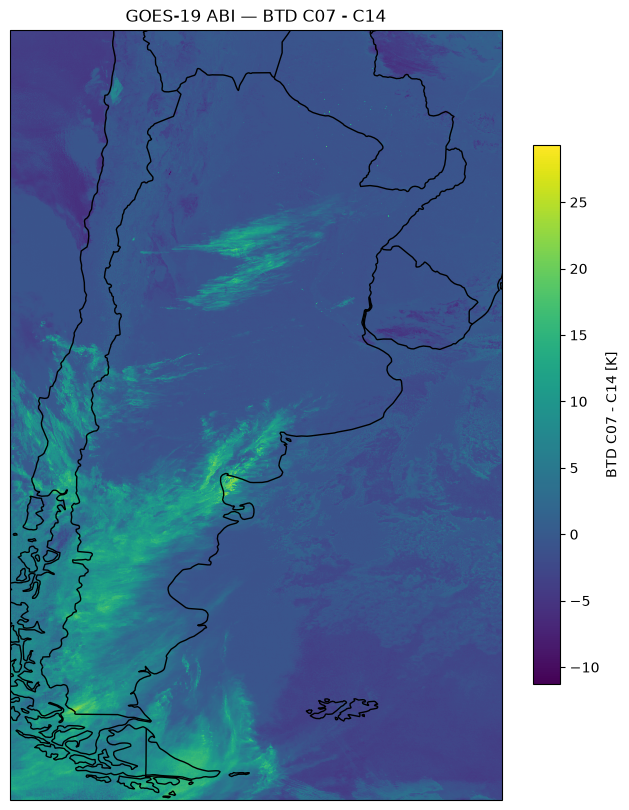

In [7]:
# ============================================================
# VISUALIZACIÓN DE BTD C07 - C14 SOBRE ARGENTINA
# ============================================================
# Graficamos la diferencia de temperatura de brillo (BTD)
# entre los canales C07 (3.9 µm) y C14 (11.2 µm).
#
# BTD = Tb(C07) - Tb(C14)
#
# Los valores positivos indican que C07 presenta una temperatura
# de brillo mayor que C14. Las anomalías térmicas pueden producir
# diferencias positivas importantes, aunque una BTD elevada por
# sí sola no implica necesariamente la presencia de un incendio.



fig = plt.figure(figsize=(8, 10))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# Representamos la diferencia C07 - C14.
img = ax.pcolormesh(
    lon_arg,
    lat_arg,
    BTD_arg,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

# Referencias geográficas.
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS)

# Barra de colores.
cbar = plt.colorbar(img, ax=ax, shrink=0.7)
cbar.set_label("BTD C07 - C14 [K]")

ax.set_title("GOES-19 ABI — BTD C07 - C14")

plt.show()

### Inspección de candidatos

Se muestran las variables principales de los píxeles seleccionados para facilitar la inspección de los resultados durante el desarrollo.

In [8]:
# ============================================================
# INSPECCIÓN DE LOS MAYORES VALORES DE BTD
# ============================================================
# Identificamos los 20 píxeles con mayor diferencia C07 - C14
# dentro de la región de estudio.
#
# Para cada píxel mostramos:
#   - latitud y longitud
#   - temperatura de brillo C07
#   - temperatura de brillo C14
#   - BTD
#
# Este análisis es exploratorio: permite distinguir si los
# máximos corresponden a superficies calientes, nubes frías
# u otro tipo de señal antes de definir criterios de detección.

# Convertimos temporalmente las matrices a vectores.
btd_flat = BTD_arg.ravel()

# Consideramos solamente valores válidos.
validos = np.isfinite(btd_flat)

indices_validos = np.where(validos)[0]

# Ordenamos los píxeles válidos por BTD y seleccionamos los 20 mayores.
top20 = indices_validos[
    np.argsort(btd_flat[validos])[-20:]
][::-1]

print("   LAT       LON       C07 [K]   C14 [K]   BTD [K]")
print("------------------------------------------------------")

for idx in top20:

    j, i = np.unravel_index(idx, BTD_arg.shape)

    print(
        f"{lat_arg[j,i]:8.3f}  "
        f"{lon_arg[j,i]:9.3f}  "
        f"{Tb_c07_arg[j,i]:8.2f}  "
        f"{Tb_c14_arg[j,i]:8.2f}  "
        f"{BTD_arg[j,i]:8.2f}"
    )

   LAT       LON       C07 [K]   C14 [K]   BTD [K]
------------------------------------------------------
 -23.838    -60.061    319.99    290.73     29.26
 -24.425    -59.062    314.38    288.62     25.76
 -40.927    -64.668    258.58    233.65     24.93
 -40.925    -64.745    251.09    227.00     24.09
 -35.178    -66.173    305.01    280.97     24.05
 -41.124    -64.606    249.12    226.06     23.07
 -23.918    -60.261    313.05    290.07     22.98
 -51.817    -71.947    251.09    228.12     22.97
 -40.926    -64.693    256.77    233.83     22.94
 -40.958    -64.508    252.59    229.68     22.91
 -40.899    -64.673    252.59    229.68     22.91
 -51.704    -71.830    248.78    226.06     22.72
 -41.016    -64.447    252.01    229.29     22.71
 -51.705    -71.799    249.80    227.13     22.67
 -51.817    -71.978    249.47    226.80     22.67
 -41.711    -64.886    257.47    234.84     22.62
 -51.742    -71.890    248.06    225.44     22.62
 -40.898    -64.724    254.79    232.19     

## 8. Preselección nocturna de anomalías térmicas

Se realiza una primera selección de píxeles térmicamente interesantes a partir de criterios utilizados en el algoritmo **NOAA ABI Fire Detection and Characterization (FDCA)**.

Para este caso nocturno se consideran la diferencia **C07 − C14**, la temperatura de brillo de **C07** y la temperatura de **C14** para descartar gran parte de la nubosidad fría.

Esta etapa constituye una preselección; la identificación de incendios requiere posteriormente el análisis contextual de cada candidato respecto de su entorno.

In [9]:
# ============================================================
# PRESELECCIÓN NOCTURNA DE PÍXELES TÉRMICAMENTE ANÓMALOS
# ============================================================
# Aplicamos una primera selección basada en los criterios
# iniciales del algoritmo NOAA ABI Fire Detection and
# Characterization Algorithm (FDCA).
#
# Para este caso nocturno:
#
#   - C07 - C14 debe superar 2 K.
#   - C07 debe alcanzar al menos 285 K.
#   - C14 >= 270 K evita el test básico de nube fría.
#
# Esta etapa NO identifica todavía incendios.
# Solamente selecciona píxeles que justifican continuar
# con el análisis contextual del entorno.

candidatos_iniciales = (
    (BTD_arg > 2) &
    (Tb_c07_arg >= 285) &
    (Tb_c14_arg >= 270)
)

print("Píxeles que pasan la preselección:",
      np.sum(candidatos_iniciales))

Píxeles que pasan la preselección: 739


## 9. Visualización de candidatos iniciales

Se representa el campo **BTD C07 − C14** y se superponen los píxeles que pasaron la preselección nocturna.

Los puntos señalados corresponden a **candidatos térmicos iniciales** que deberán ser evaluados posteriormente mediante el análisis contextual de su entorno.

C:\Users\zeitune\miniconda3\envs\goes_fire\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\zeitune\miniconda3\envs\goes_fire\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\zeitune\miniconda3\envs\goes_fire\Lib\site-packages\cartopy\mpl\geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
C:\Users\zeitune\miniconda3\envs\goes_fire\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\zeitune\miniconda3\envs\goes_fire\Lib\site-packages\cartopy\mpl\geoaxes.py:509: User

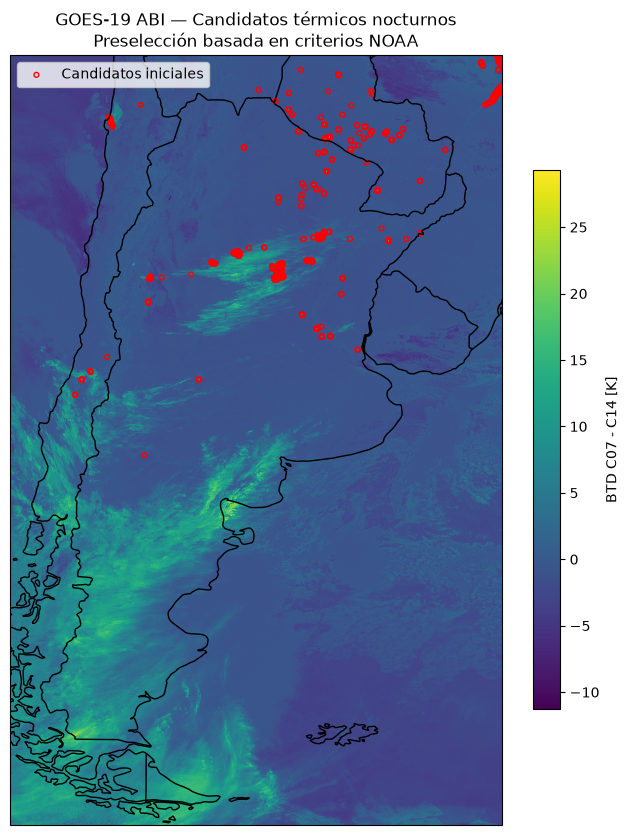

In [10]:
# ============================================================
# VISUALIZACIÓN DE LOS CANDIDATOS INICIALES
# ============================================================
# Mostramos el campo BTD C07-C14 como fondo y superponemos
# únicamente los píxeles que pasaron la preselección nocturna.
#
# Estos puntos NO representan todavía incendios confirmados.
# Son píxeles térmicamente interesantes que deberán ser
# evaluados posteriormente mediante tests contextuales.

fig = plt.figure(figsize=(8, 10))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# Campo BTD de fondo
img = ax.pcolormesh(
    lon_arg,
    lat_arg,
    BTD_arg,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

# Píxeles que pasaron la preselección
ax.scatter(
    lon_arg[candidatos_iniciales],
    lat_arg[candidatos_iniciales],
    s=12,
    marker="o",
    facecolors="none",
    edgecolors="red",
    transform=ccrs.PlateCarree(),
    label="Candidatos iniciales"
)

ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS)

cbar = plt.colorbar(img, ax=ax, shrink=0.7)
cbar.set_label("BTD C07 - C14 [K]")

ax.legend()

ax.set_title(
    "GOES-19 ABI — Candidatos térmicos nocturnos\n"
    "Preselección basada en criterios NOAA"
)

plt.show()